# KNN para Classificação de Sentimentos

Nesta etapa, os embeddings gerados pelo modelo
`all-MiniLM-L6-v2` serão utilizados como características
de entrada para um modelo KNN.

## Objetivo

Classificar as avaliações de filmes em duas classes:

- `0` = negativo
- `1` = positivo

## Etapas

1. Carregamento dos embeddings.
2. Verificação dos dados.
3. Separação entre características (`X`) e rótulos (`y`).
4. Divisão dos dados em treinamento e teste.
5. Treinamento do KNN.
6. Predição.
7. Avaliação do modelo.
8. Análise da matriz de confusão.
9. Salvamento do modelo treinado (comentado)
10. Salvamento das métricas do modelo
11. Salvamento das figuras do modelo

In [34]:
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import json
from pathlib import Path
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("../data/processed/IMDB_menor_embeddings.csv")

df.head()

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383,sentiment
0,0.028352,0.058333,-0.069887,0.068288,0.080217,0.069166,0.040935,0.024101,0.073692,-0.060215,...,-0.078145,-0.024825,0.016664,0.013412,0.020879,0.065421,-0.025376,-0.050503,-0.025903,1
1,0.008254,0.065314,-0.004735,-0.051875,0.020606,0.084680,0.021552,0.006631,-0.015105,-0.015956,...,0.036724,0.038877,0.004208,-0.072306,0.010558,0.030873,0.010355,-0.050139,0.005361,1
2,0.014115,-0.076151,0.000104,0.013555,0.075392,0.070780,0.089844,0.067970,-0.018511,0.013720,...,-0.083469,-0.130850,0.057835,-0.062770,0.041212,0.055430,-0.030518,-0.000004,-0.083408,1
3,-0.051149,0.010064,-0.058461,-0.029110,0.056663,0.086137,0.018702,-0.010250,0.084562,-0.042020,...,-0.036892,0.000891,-0.016270,-0.003118,0.024032,0.069954,-0.015741,0.014551,0.015636,0
4,-0.040961,-0.015201,-0.030476,-0.034416,-0.023004,0.049733,0.055261,0.000040,0.111896,-0.046311,...,-0.009982,-0.027761,0.108200,-0.008198,-0.013424,0.011123,-0.027719,0.008909,0.026550,1


In [18]:
COLUNA_ROTULO = "sentiment"

y = df[COLUNA_ROTULO].values
X = df.drop(columns=[COLUNA_ROTULO]).values.astype(float)

print(X.shape, y.shape)
print(np.unique(y, return_counts=True))

(2000, 384) (2000,)
(array([0, 1]), array([ 995, 1005]))


In [19]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
busca = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={
        "n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31, 41, 51, 71, 101],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "cosine"],
    },
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
)
busca.fit(X_train, y_train)
print(busca.best_params_)

{'metric': 'cosine', 'n_neighbors': 31, 'weights': 'distance'}


              precision    recall  f1-score   support

           0       0.69      0.87      0.77       199
           1       0.83      0.61      0.70       201

    accuracy                           0.74       400
   macro avg       0.76      0.74      0.74       400
weighted avg       0.76      0.74      0.74       400



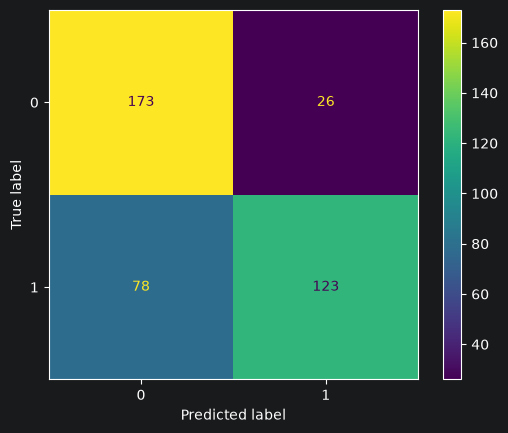

In [22]:
modelo = busca.best_estimator_
y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

In [36]:
#joblib.dump(modelo, "../src/models/knn_v1.joblib")

In [30]:
METRICS = Path("../results/metrics/knn")
FIGURES = Path("../results/figures/knn")
METRICS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

In [31]:
rel = classification_report(y_test, y_pred, output_dict=True)
pd.DataFrame(rel).transpose().to_csv(METRICS / "knn_v1_classification_report.csv")

In [32]:
resumo = {
    "best_params": busca.best_params_,
    "cv_f1_macro": busca.best_score_,
    "test_f1_macro": rel["macro avg"]["f1-score"],
    "test_accuracy": rel["accuracy"],
}
with open(METRICS / "knn_v1_resumo.json", "w") as f:
    json.dump(resumo, f, indent=2, default=str)


In [33]:
pd.DataFrame(busca.cv_results_).to_csv(METRICS / "knn_v1_gridsearch.csv", index=False)

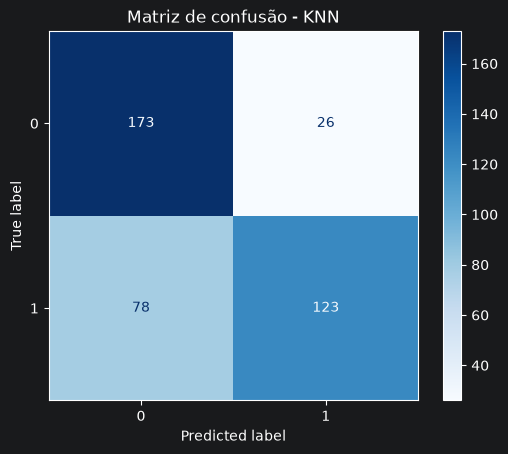

In [35]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
disp.ax_.set_title("Matriz de confusão - KNN")
plt.savefig(FIGURES / "knn_v1_matriz_confusao.png", dpi=300, bbox_inches="tight")
plt.show()